In [2]:
#Importing libraries

import pandas as pd  
import numpy as np
import matplotlib.pyplot as plt  
import seaborn as sns  



In [3]:
#Loading the dataset
#first, we will define the URL

url = " https://raw.githubusercontent.com/sik-flow/new_data1/refs/heads/main/Wholesale%20customers%20data.csv"
df = pd.read_csv(url)

#preview data

df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


This dataset shows wholesale customers, represented by the index numbers, the payment channel of choice(1 or 2), the region of purchase(1, 2, or 3), and the items bought.


In [4]:
df.sample(10)

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
380,1,3,28257,944,2146,3881,600,270
220,1,1,14755,899,1382,1765,56,749
225,1,1,12680,3243,4157,660,761,786
397,1,3,11535,1666,1428,6838,64,743
159,2,3,355,7704,14682,398,8077,303
163,2,3,5531,15726,26870,2367,13726,446
234,1,1,15603,2703,3833,4260,325,2563
307,1,2,17327,2374,2842,1149,351,925
308,1,2,6987,1020,3007,416,257,656
261,1,1,7858,1110,1094,6818,49,287


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


In [6]:
df.shape

(440, 8)

In [7]:
# Data Wrangling and cleaning
df.describe()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,1.322727,2.543182,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,0.468052,0.774272,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,1.000000,1.000000,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,1.000000,2.000000,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,1.000000,3.000000,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,2.000000,3.000000,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000
max,2.000000,3.000000,112151.000000,73498.000000,92780.000000,60869.000000,40827.000000,47943.000000


In [8]:
#Checking for missing values... no null values. COOL.
df.isnull().sum()

Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64

In [9]:
# Data wrangling
# Details on the Channel column.
df['Channel'].value_counts()

Channel
1    298
2    142
Name: count, dtype: int64

Most of the customers preferred channel 1 to channel 2. Over twice the number of customers preferred channel 1 (298) to channel 2 (142).

In [10]:
# Looking at the proportion of customers among the regions.

df['Region'].value_counts(normalize=True)

Region
3    0.718182
1    0.175000
2    0.106818
Name: proportion, dtype: float64

Most of the customers are from region 3, with 71.82% of the purchases coming from the region, 17.5% of the purchases come from region 1 and 10.68% from region 2.

The two features, Channel and Region, seem to be rather interesting to look into to identify which customers require different forms and levels of advertising.

In [11]:
# Looking at the relationship between channel and region.

df.groupby('Region')['Channel'].mean()

Region
1    1.233766
2    1.404255
3    1.332278
Name: Channel, dtype: float64

It seems that the choice of channel among the regiond is pretty much even.

It would also be interesting to look at the products and see the preferrences.

In [12]:
# Relationship between the Regions and Milk
df.groupby('Region')['Milk'].mean()

Region
1    5486.415584
2    5088.170213
3    5977.085443
Name: Milk, dtype: float64

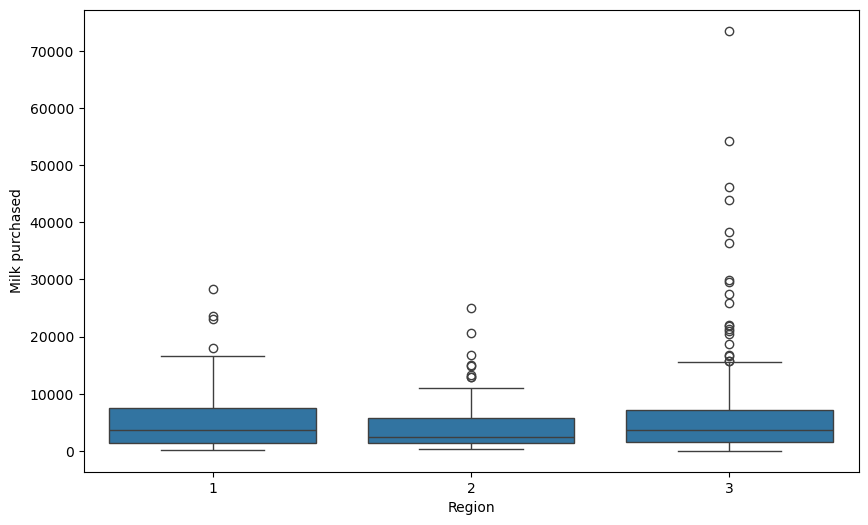

In [13]:
# Lets plot this out
X = df['Region']
y = df['Milk']

plt.figure(figsize=(10, 6))
sns.boxplot(x=X, y=y)
plt.xlabel('Region')
plt.ylabel('Milk purchased')
plt.show()

The purchase of milk among the Regions is pretty much even, but region 3 buys the most Milk, then Region 1 and then 2. Region 3 also has the most outliers with a section of the customers making the most purchases.

In [14]:
# Relationship between the Regions and Frozen columns
df.groupby('Region')['Frozen'].mean()

Region
1    3000.337662
2    4045.361702
3    2944.594937
Name: Frozen, dtype: float64

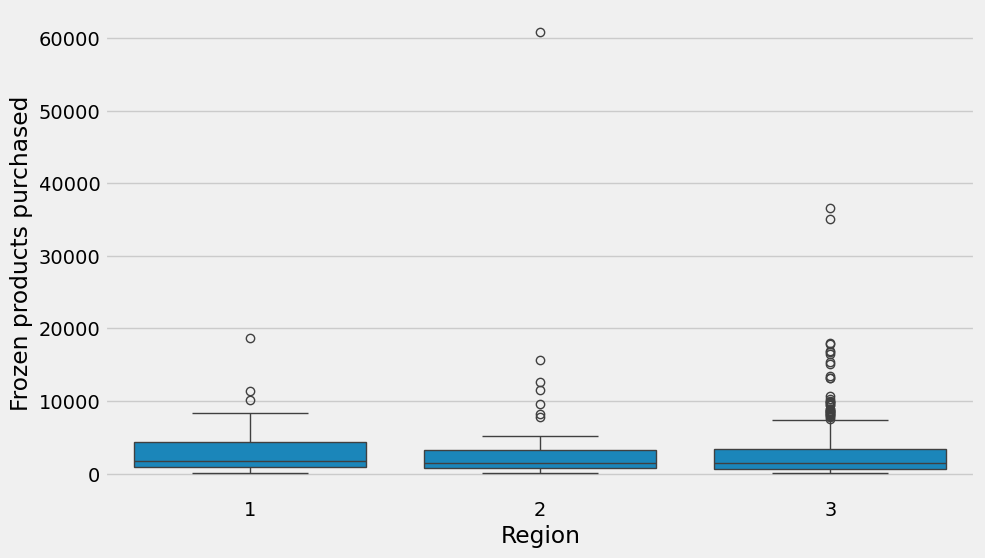

In [56]:
# Lets plot this out
X = df['Region']
y = df['Frozen']

plt.figure(figsize=(10, 6))
sns.boxplot(x=X, y=y)
plt.xlabel('Region')
plt.ylabel('Frozen products purchased')
plt.show()

The purchase of Frozen products seems to be mostly in Region 2, with Regions 1 and 3 looking slightly similar. One customer from Region two seems to have made the most purchases overall. Interesting.

In [16]:
# Relationship between the Regions and Fresh columns
df.groupby('Region')['Fresh'].mean()

Region
1    11101.727273
2     9887.680851
3    12533.471519
Name: Fresh, dtype: float64

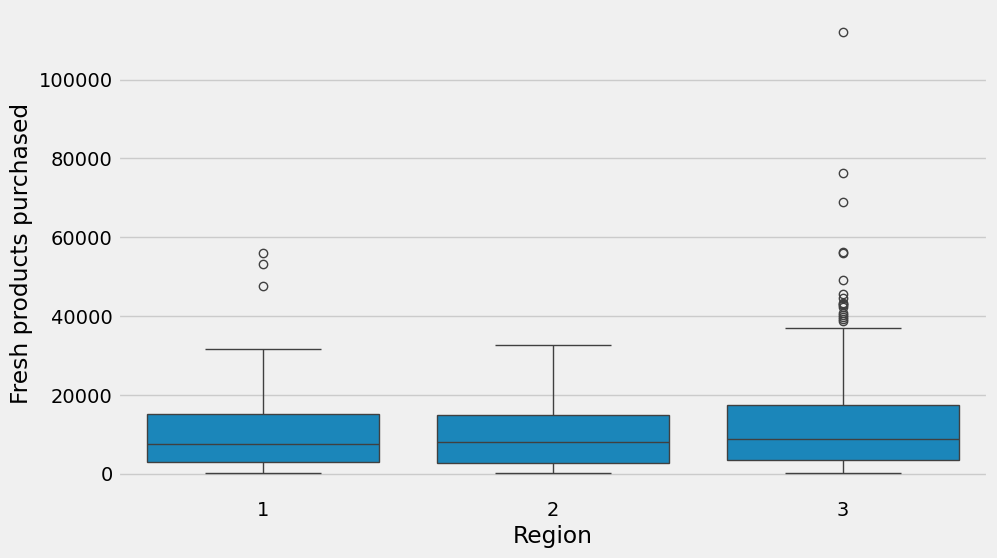

In [57]:
# Lets plot this out
X = df['Region']
y = df['Fresh']

plt.figure(figsize=(10, 6))
sns.boxplot(x=X, y=y)
plt.xlabel('Region')
plt.ylabel('Fresh products purchased')
plt.show()

In this, Region 3 has the highest purchase of Fresh products, then Region 1 and 2 respectively. Quite a number of outliers in Region 3 buying the most Fresh products. 

In [18]:
# Relationship between the regions and  Grocery columns.
df.groupby('Region')['Grocery'].mean()

Region
1    7403.077922
2    9218.595745
3    7896.363924
Name: Grocery, dtype: float64

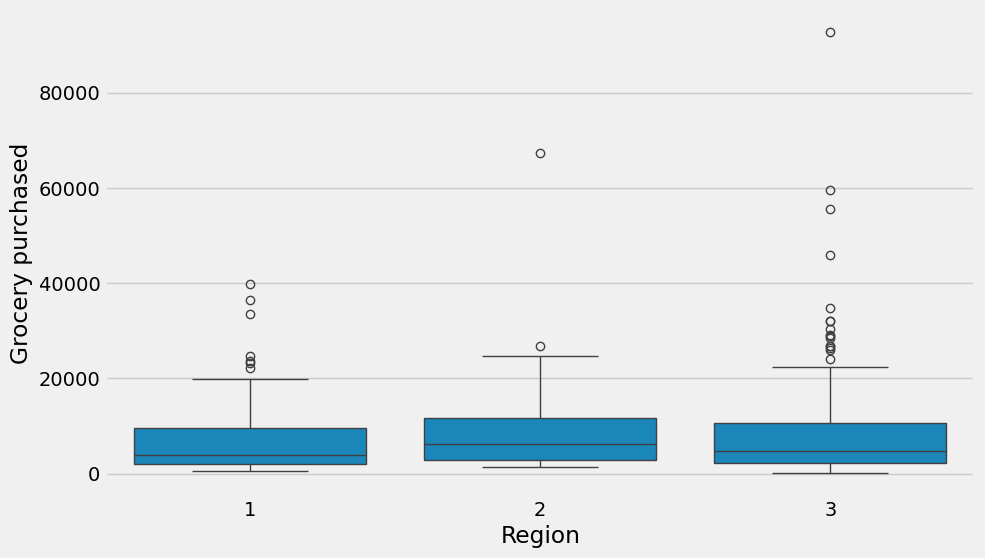

In [58]:
# Lets plot this out
X = df['Region']
y = df['Grocery']

plt.figure(figsize=(10, 6))
sns.boxplot(x=X, y=y)
plt.xlabel('Region')
plt.ylabel('Grocery purchased')
plt.show()

Here, Region 2 has the highest mean purchase, while Region 3 and 1. Some outliers in Region 3 buying the most Grocery.  

In [20]:
df.groupby('Region')['Detergents_Paper'].mean()

Region
1    2651.116883
2    3687.468085
3    2817.753165
Name: Detergents_Paper, dtype: float64

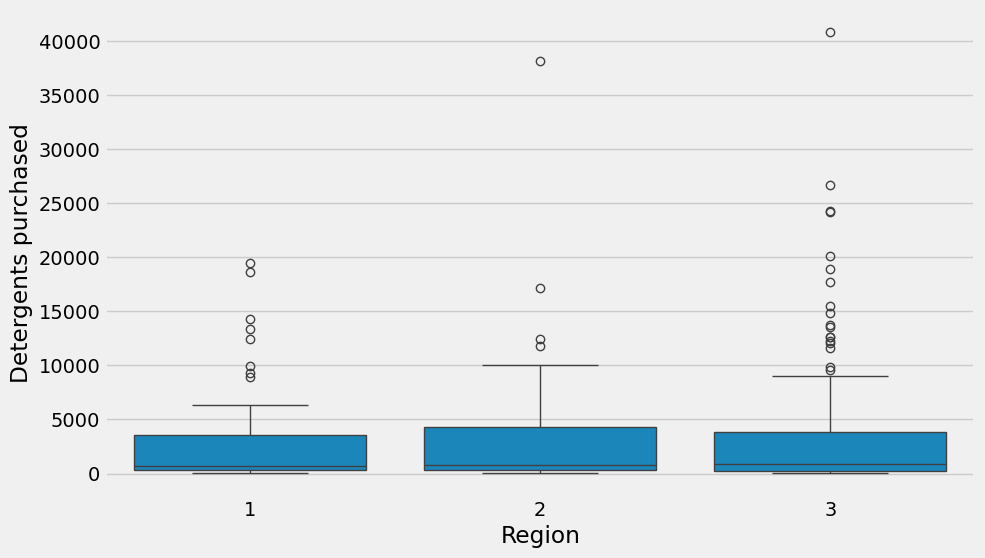

In [59]:
# Lets plot this out
X = df['Region']
y = df['Detergents_Paper']

plt.figure(figsize=(10, 6))
sns.boxplot(x=X, y=y)
plt.xlabel('Region')
plt.ylabel('Detergents purchased')
plt.show()

Region 2 seems to have the most purchases of Detergents, with Region 3 and 1 seemingly close (but Region 3 has slightly more). Region 3 has some outlying customers with high purchases.

In [22]:
df.groupby('Region')['Delicassen'].mean()

Region
1    1354.896104
2    1159.702128
3    1620.601266
Name: Delicassen, dtype: float64

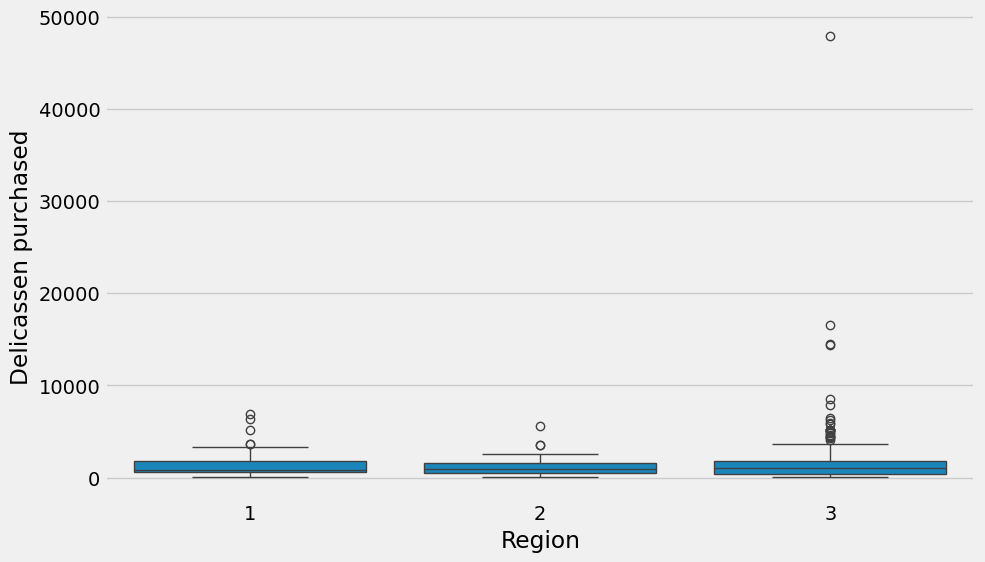

In [60]:
# Lets plot this out
X = df['Region']
y = df['Delicassen']

plt.figure(figsize=(10, 6))
sns.boxplot(x=X, y=y)
plt.xlabel('Region')
plt.ylabel('Delicassen purchased')
plt.show()

The purchases of Delicassen seem rather low compared to the other products, and mostly even among the regions. Region 3 does have the highest mean purchase with some of the customers buying the most Delicassen. 

We will be focusing on the relationship between the customers' regions and and the products. Mostly because it does not really matter which Channel the customers used to purchase the products, but also, the proportion between the Channels seem to be very much even.  

Time to make clusters for Customer Segmentation

In [24]:
# First, lets get the columns of interest. Here, I think the products would be useful. The other columns seem to already classify the customers.

cols = ['Grocery', 'Milk', 'Fresh', 'Frozen', 'Detergents_Paper', 'Delicassen']
df_new = df[cols].copy()
df_new.head()


,Grocery,Milk,Fresh,Frozen,Detergents_Paper,Delicassen
0,7561,9656,12669,214,2674,1338
1,9568,9810,7057,1762,3293,1776
2,7684,8808,6353,2405,3516,7844
3,4221,1196,13265,6404,507,1788
4,7198,5410,22615,3915,1777,5185


In [25]:
# Standardizing the columns of interest.

from sklearn.preprocessing import StandardScaler

ss = StandardScaler()

scaled_df_new = ss.fit_transform(df_new)

In [26]:
# Instantilizing a KMeans Clustering
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(scaled_df_new)

clusters

c:\Users\chept\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


array([3, 0, 0, 3, 3, 3, 3, 3, 3, 0, 0, 3, 0, 0, 0, 3, 0, 3, 3, 3, 3, 3,
       3, 1, 0, 3, 3, 3, 0, 3, 3, 3, 3, 3, 3, 0, 3, 0, 0, 3, 3, 3, 0, 0,
       0, 0, 0, 2, 0, 0, 3, 3, 3, 0, 3, 3, 2, 0, 3, 3, 3, 2, 3, 0, 3, 2,
       3, 0, 3, 3, 3, 1, 3, 3, 3, 3, 3, 0, 3, 3, 3, 0, 0, 3, 3, 2, 2, 1,
       3, 3, 3, 3, 2, 1, 0, 3, 3, 3, 3, 3, 0, 0, 0, 3, 3, 3, 0, 0, 0, 0,
       3, 0, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 0, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 0, 0, 3, 0, 0, 0, 3, 3, 0, 0, 0, 0, 3, 3, 3, 0, 0, 3, 0, 3, 0,
       3, 3, 3, 3, 3, 1, 0, 1, 3, 3, 3, 0, 0, 0, 3, 3, 3, 0, 3, 3, 3, 0,
       3, 3, 0, 0, 3, 3, 3, 0, 3, 3, 3, 0, 3, 2, 3, 0, 0, 0, 0, 3, 0, 3,
       3, 0, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 0, 0, 3, 3, 3, 3, 3, 2, 3, 3, 0, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       0, 0, 0, 3, 0, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 0, 3, 3, 3, 3, 0, 3, 3,

In [27]:
# Checking the lengths
len(scaled_df_new), len(clusters)

(440, 440)

In [28]:
# Checking the silhouette score
from sklearn.metrics import silhouette_score

silhouette_score(scaled_df_new, clusters)

0.34939129340421093

A silhouette score of 0.349 might not be the best. We will need to identify the best number of clusters to use.

In [29]:
# A for loop to identify the best value for n_clusters.

silhouette_score_list = []

for i in range(2,11):
    kmeans = KMeans(n_clusters= i, random_state=42)
    cluster = kmeans.fit_predict(scaled_df_new)
    silhouette_score_list.append(silhouette_score(scaled_df_new, cluster))

c:\Users\chept\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\chept\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\chept\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\chept\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

In [30]:
print(silhouette_score_list)

[0.3998278091730005, 0.4582633767207058, 0.34939129340421093, 0.36890127429678043, 0.2762464573058837, 0.27667826866342105, 0.32366546538940916, 0.29453704649783113, 0.22876866444760022]


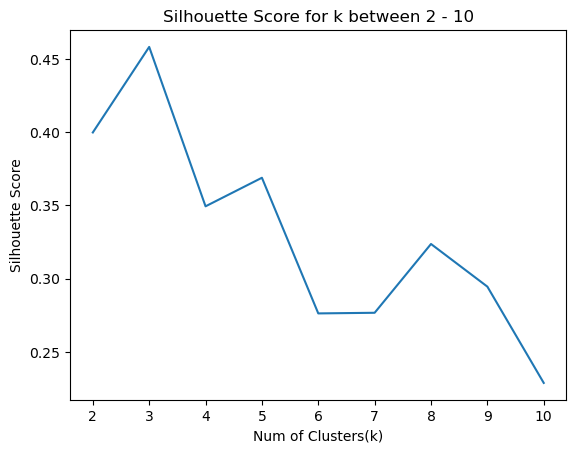

In [31]:
# Plotting this.
plt.plot(range(2,11), silhouette_score_list)
plt.xlabel('Num of Clusters(k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for k between 2 - 10')
plt.show()

A n_cluster value of 3 seems to have the best Silhouette score.

c:\Users\chept\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\chept\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\chept\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\chept\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

Text(0.5, 1.0, 'Elbow Plot')

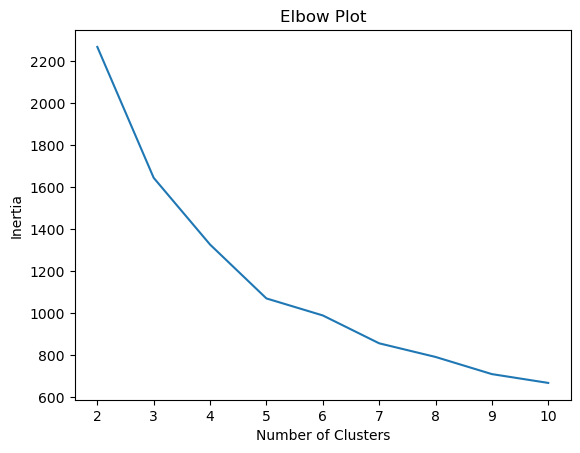

In [32]:
# Let's confirm this using the Elbow Method

# Testing the k values between 2 and 10

inertia_list = []

for j in range(2,11):
    kmean = KMeans(n_clusters=j, random_state=42)
    kmean.fit(scaled_df_new)
    inertia_list.append(kmean.inertia_)

# Plotting the inertia list against the number of clusters.

plt.plot(range(2,11), inertia_list)
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Plot')

According to the Elbow Plot, 5 seems to be the best k value. We will consider the Silhouette Score for now.

In [33]:
# Instantilizing the KMeans Clustering with the best number of clusters basing on the Silhouette Score

kmeans = KMeans(n_clusters=3, random_state=42)
clusters_sc = kmeans.fit_predict(scaled_df_new)

c:\Users\chept\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


We will need to visualize the clusters to also determine the best number of clusters.

In [34]:
# Visualizing the clusters.
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2)
tsne_data = tsne.fit_transform(scaled_df_new)

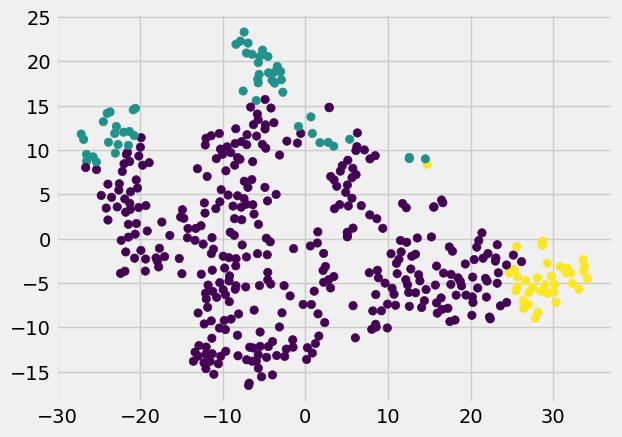

In [35]:
# Plotting the clusters
plt.style.use('fivethirtyeight')

plt.scatter(tsne_data[:, 0], tsne_data[:, 1], c=clusters_sc)

Maybe a k value of 5 would look better.

In [36]:
# Instantilizing the KMeans Clustering with the best number of clusters basing on the Elbow Plot

kmeans = KMeans(n_clusters=5, random_state=42)
clusters_elbow = kmeans.fit_predict(scaled_df_new)

c:\Users\chept\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


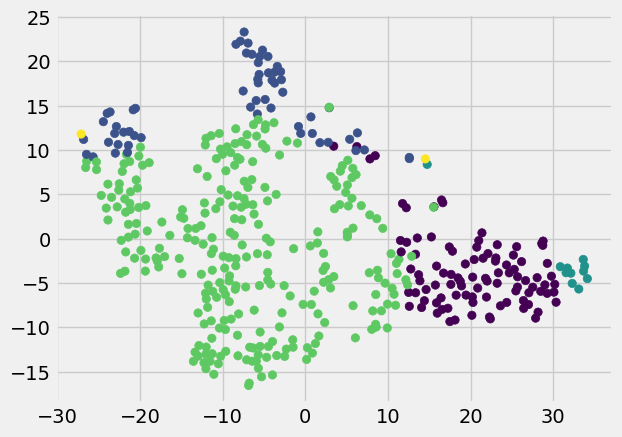

In [37]:
# Plotting the clusters
plt.style.use('fivethirtyeight')

plt.scatter(tsne_data[:, 0], tsne_data[:, 1], c=clusters_elbow)

This plot seems to have some far placed clusters. The plot for k = 3 seems to segment the data better.

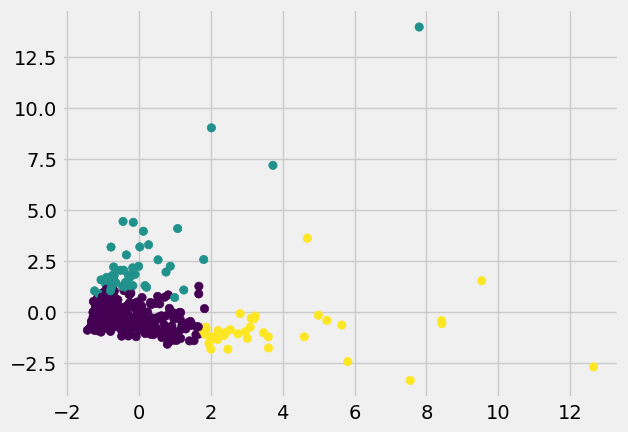

In [38]:
# Instantilizing a PCA with Silhouette Score considered
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_df_new)

plt.style.use('fivethirtyeight')
plt.scatter(pca_data[:, 0], pca_data[:, 1], c=clusters_sc)

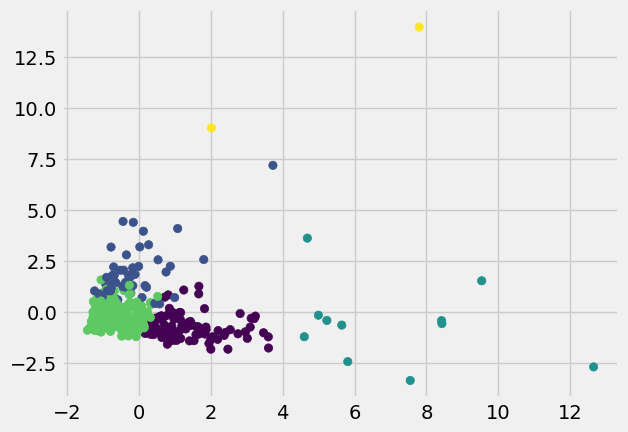

In [39]:
# Instantilizing a PCA with Elbow Plot considered
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_df_new)

plt.style.use('fivethirtyeight')
plt.scatter(pca_data[:, 0], pca_data[:, 1], c=clusters_elbow)

From the PCA graphs, a cluster number of 5 seems to be better as it groups outliers in their own segments. This seems to be ideal for Customer Segmentation to better capture unique customers. 

c:\Users\chept\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


For n_clusters = 2 The average silhouette_score is : 0.3998278091730005


c:\Users\chept\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\chept\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


For n_clusters = 3 The average silhouette_score is : 0.4582633767207058
For n_clusters = 4 The average silhouette_score is : 0.34939129340421093


c:\Users\chept\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\chept\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


For n_clusters = 5 The average silhouette_score is : 0.36890127429678043
For n_clusters = 6 The average silhouette_score is : 0.2762464573058837


c:\Users\chept\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


For n_clusters = 10 The average silhouette_score is : 0.22876866444760022


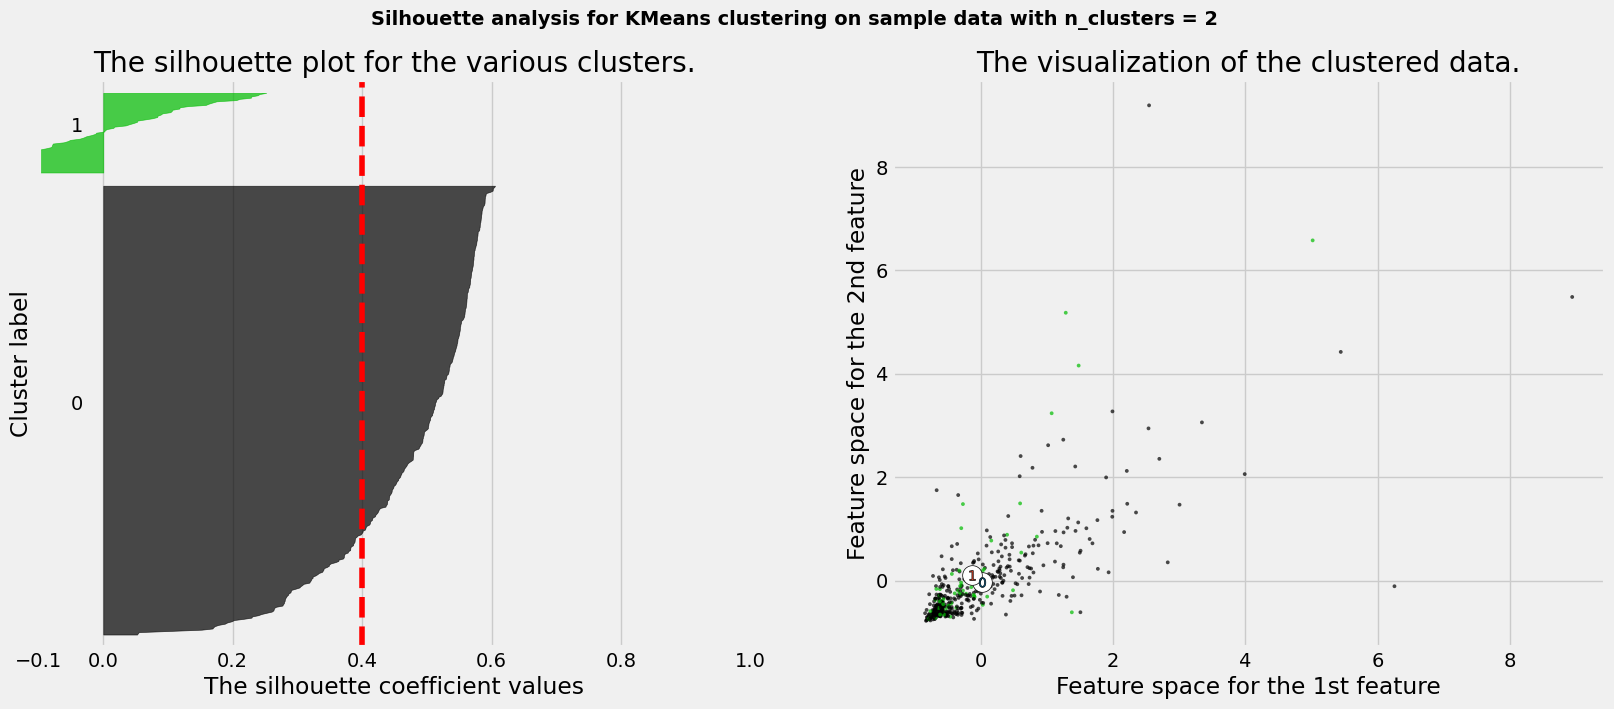

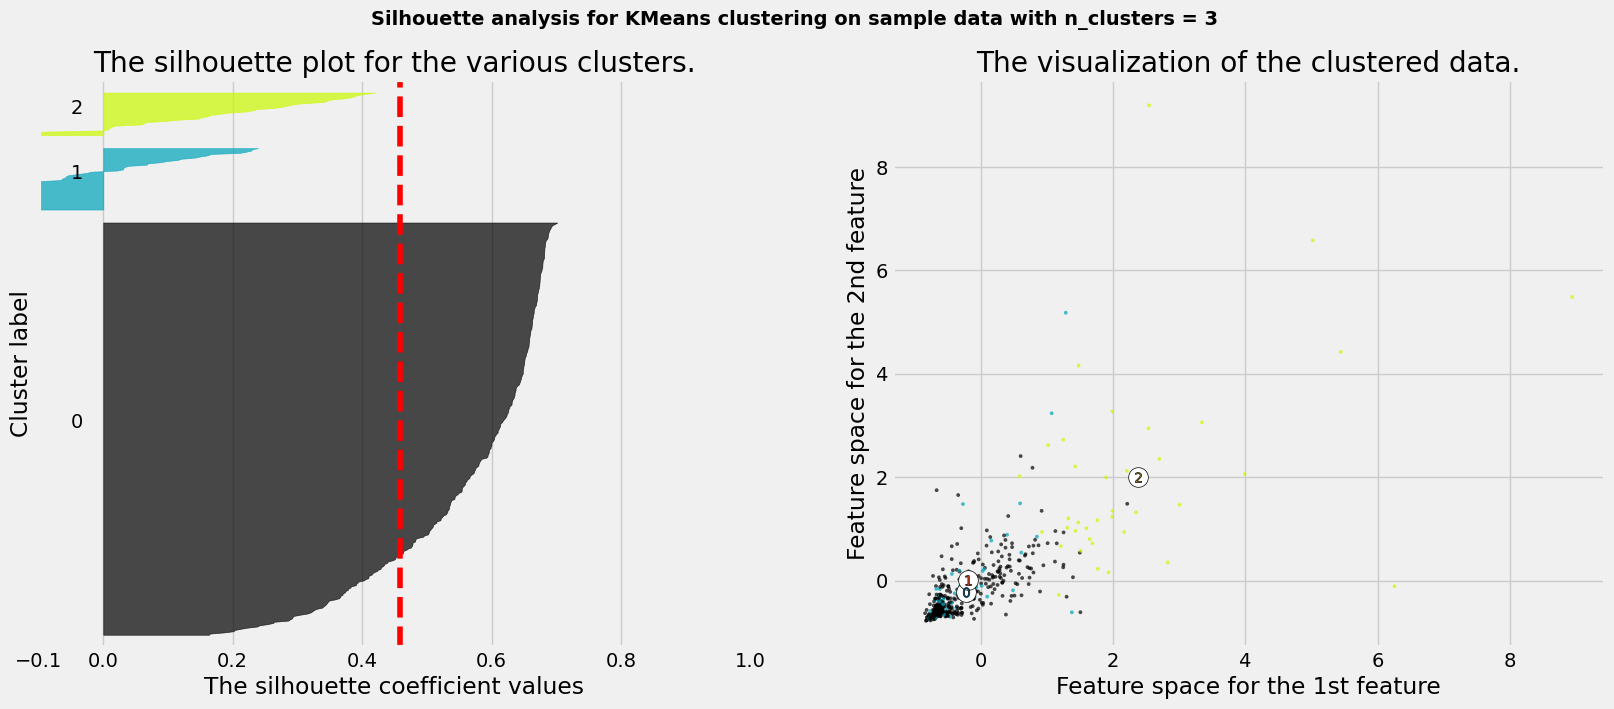

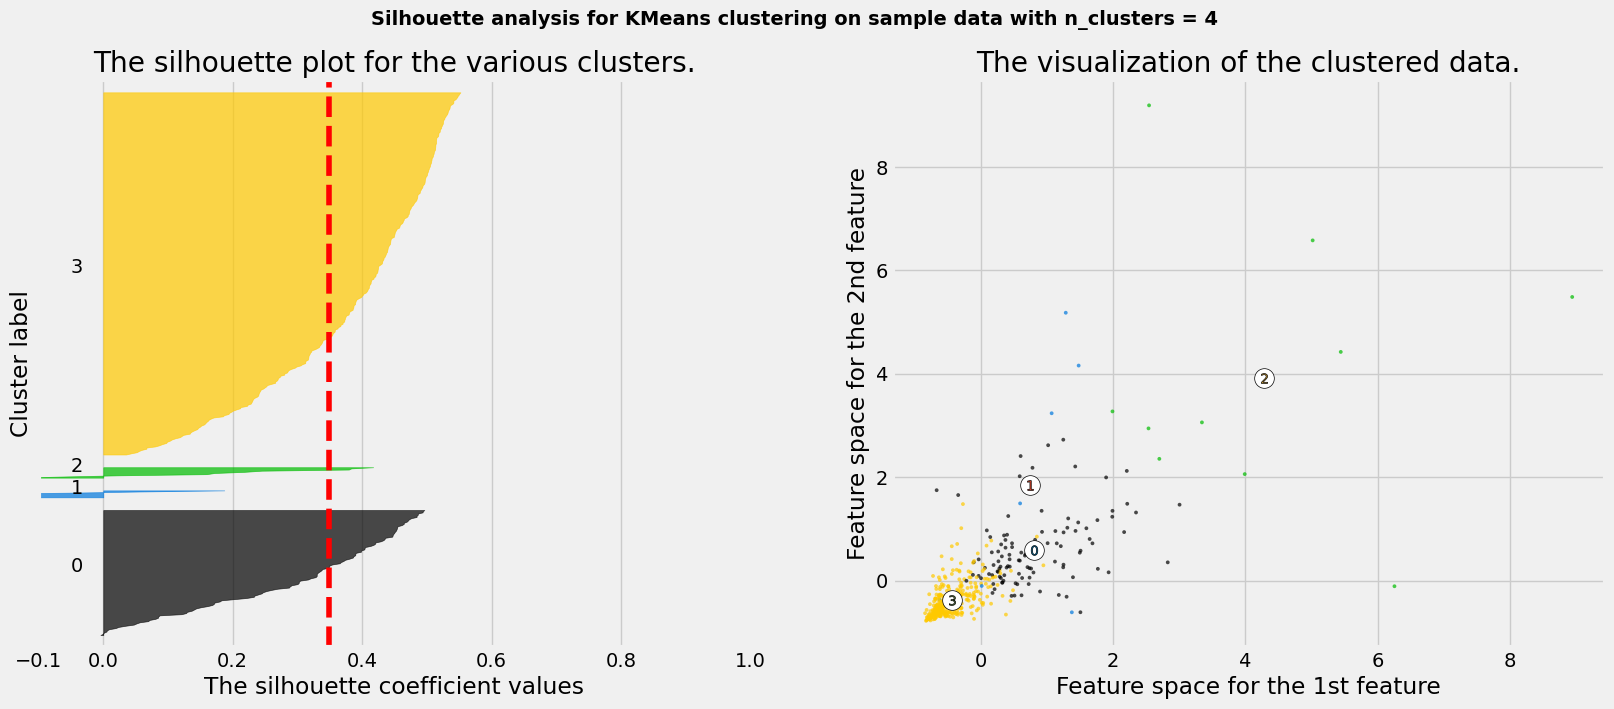

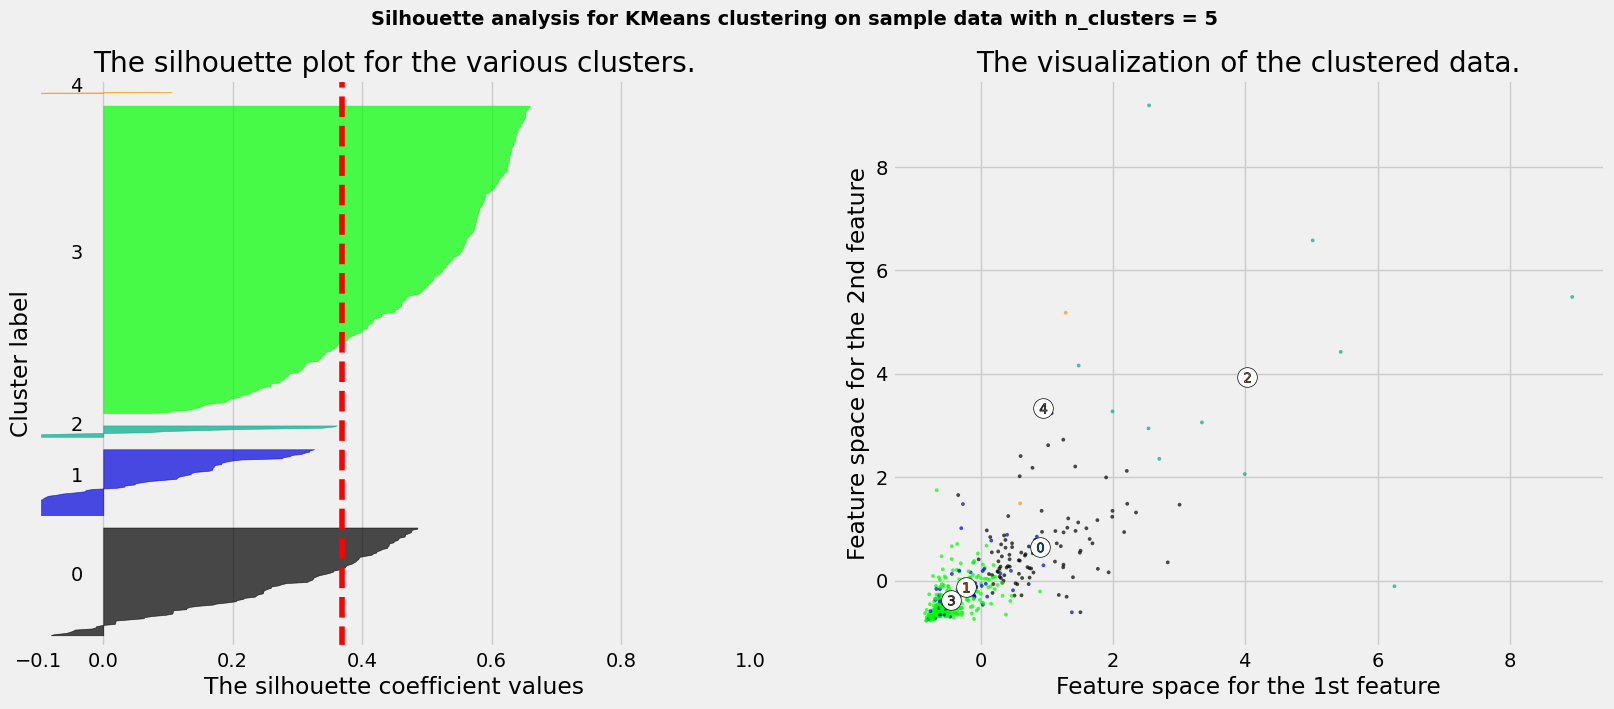

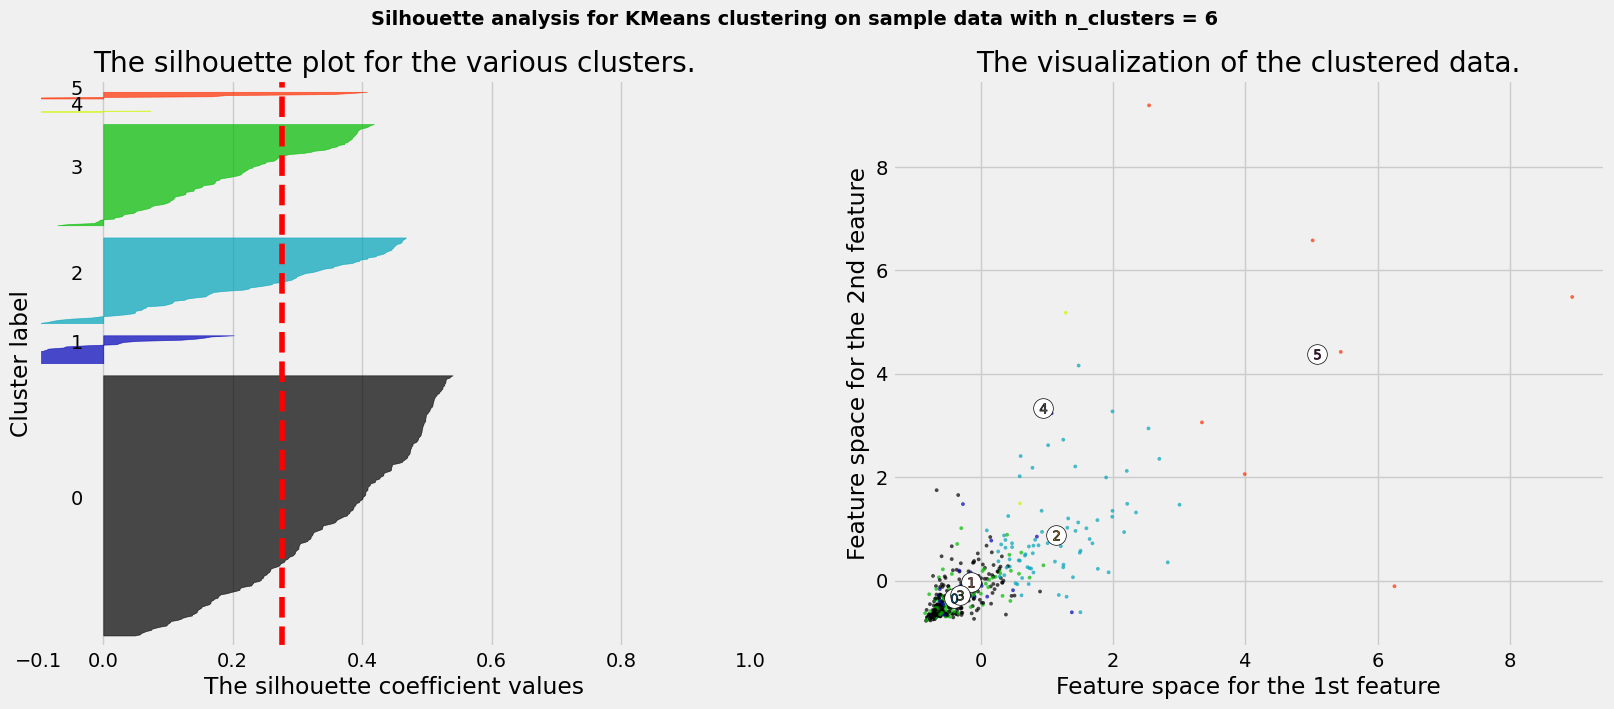

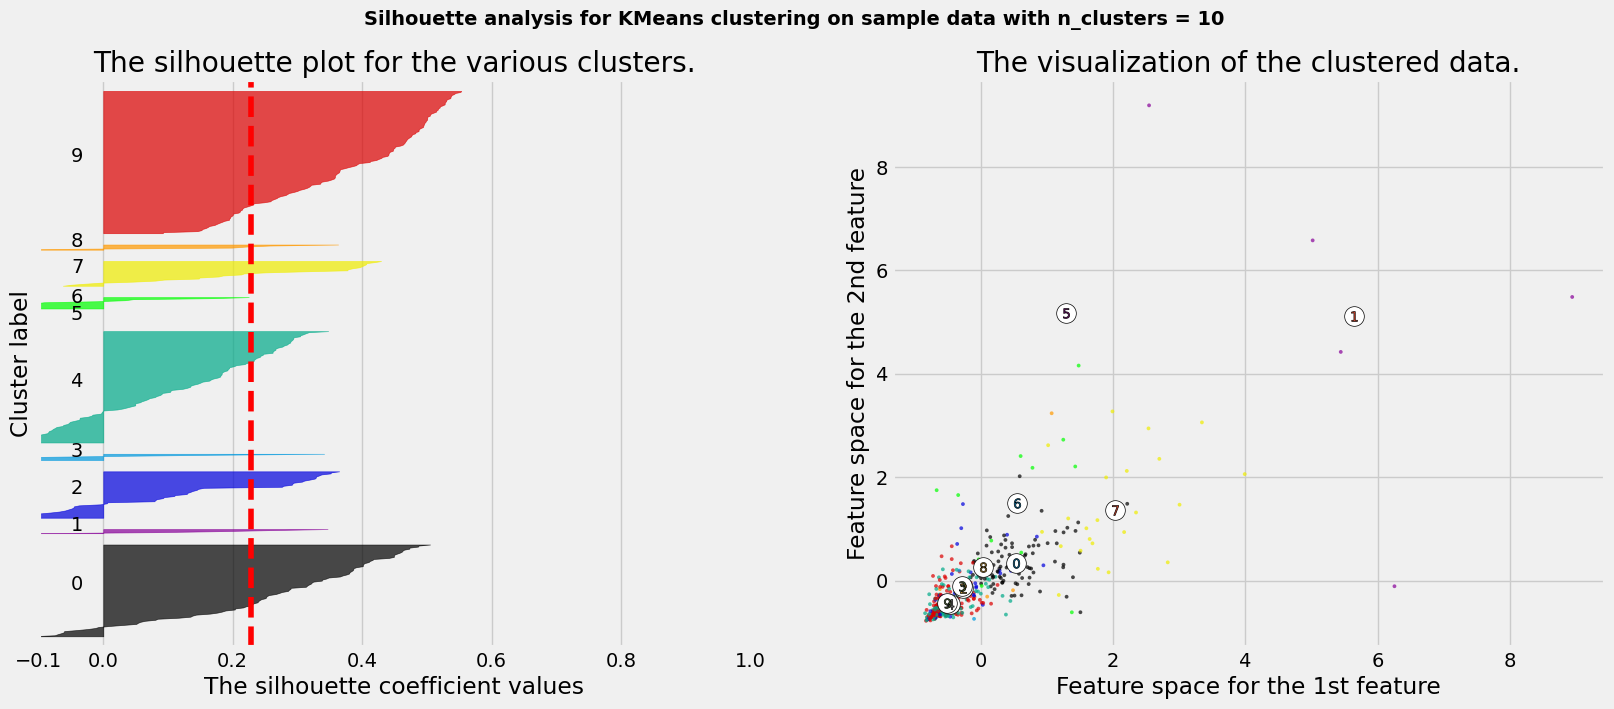

In [40]:
# Authors: The scikit-learn developers
# SPDX-License-Identifier: BSD-3-Clause

import matplotlib.cm as cm
#import matplotlib.pyplot as plt
#import numpy as np

#from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_samples, silhouette_score

# Generating the sample data from make_blobs
# This particular setting has one distinct cluster and 3 clusters placed close
# together.

range_n_clusters = [2, 3, 4, 5, 6, 10]

for n_clusters in range_n_clusters:
    # Create a subplot with 1 row and 2 columns
    fig, (ax1, ax2) = plt.subplots(1, 2)
    fig.set_size_inches(18, 7)

    # The 1st subplot is the silhouette plot
    # The silhouette coefficient can range from -1, 1 but in this example all
    # lie within [-0.1, 1]
    ax1.set_xlim([-0.1, 1])
    # The (n_clusters+1)*10 is for inserting blank space between silhouette
    # plots of individual clusters, to demarcate them clearly.
    ax1.set_ylim([0, len(df) + (n_clusters + 1) * 10])

    # Initialize the clusterer with n_clusters value and a random generator
    # seed of 42 for reproducibility.
    clusterer = KMeans(n_clusters=n_clusters, random_state=42)
    cluster_labels = clusterer.fit_predict(scaled_df_new)

    # The silhouette_score gives the average value for all the samples.
    # This gives a perspective into the density and separation of the formed
    # clusters
    silhouette_avg = silhouette_score(scaled_df_new, cluster_labels)
    print(
        "For n_clusters =",
        n_clusters,
        "The average silhouette_score is :",
        silhouette_avg,
    )

    # Compute the silhouette scores for each sample
    sample_silhouette_values = silhouette_samples(scaled_df_new, cluster_labels)

    y_lower = 10
    for i in range(n_clusters):
        # Aggregate the silhouette scores for samples belonging to
        # cluster i, and sort them
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]

        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_silhouette_values,
            facecolor=color,
            edgecolor=color,
            alpha=0.7,
        )

        # Label the silhouette plots with their cluster numbers at the middle
        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

        # Compute the new y_lower for next plot
        y_lower = y_upper + 10  # 10 for the 0 samples

    ax1.set_title("The silhouette plot for the various clusters.")
    ax1.set_xlabel("The silhouette coefficient values")
    ax1.set_ylabel("Cluster label")

    # The vertical line for average silhouette score of all the values
    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")

    ax1.set_yticks([])  # Clear the yaxis labels / ticks
    ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

    # 2nd Plot showing the actual clusters formed
    colors = cm.nipy_spectral(cluster_labels.astype(float) / n_clusters)
    ax2.scatter(
        scaled_df_new[:, 0], scaled_df_new[:, 1], marker=".", s=30, lw=0, alpha=0.7, c=colors, edgecolor="k"
    )

    # Labeling the clusters
    centers = clusterer.cluster_centers_
    # Draw white circles at cluster centers
    ax2.scatter(
        centers[:, 0],
        centers[:, 1],
        marker="o",
        c="white",
        alpha=1,
        s=200,
        edgecolor="k",
    )

    for i, c in enumerate(centers):
        ax2.scatter(c[0], c[1], marker="$%d$" % i, alpha=1, s=50, edgecolor="k")

    ax2.set_title("The visualization of the clustered data.")
    ax2.set_xlabel("Feature space for the 1st feature")
    ax2.set_ylabel("Feature space for the 2nd feature")

    plt.suptitle(
        "Silhouette analysis for KMeans clustering on sample data with n_clusters = %d"
        % n_clusters,
        fontsize=14,
        fontweight="bold",
    )

plt.show()

Now, we will assign each customer to a cluster and evaluate the segment stability and meaningfulness.

In [41]:
# Adding the clusters to the original dataset for evaluation.

df['clusters'] = clusters_elbow

df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,clusters
0,2,3,12669,9656,7561,214,2674,1338,3
1,2,3,7057,9810,9568,1762,3293,1776,0
2,2,3,6353,8808,7684,2405,3516,7844,0
3,1,3,13265,1196,4221,6404,507,1788,3
4,2,3,22615,5410,7198,3915,1777,5185,1


In [42]:
# Analyzing the new column
df['clusters'].value_counts(ascending=False)

clusters
3    272
0     96
1     59
2     11
4      2
Name: count, dtype: int64

Cluster 3 has the most number of customers, while clusters 2 and 4 have low numbers (11 and 2 respectively). It seems clusters 2 and 4 capture the outlying customers while cluster 3 captures the customers with the most similar purchases.  

Looking at the relationships between the clusters column and the rest of the columns would help define the clusters much better.

In [43]:
# Looking at the relationship between the clusters column and the products.

df.groupby('clusters')['Fresh'].mean()

clusters
0     5509.250000
1    34188.627119
2    16911.090909
3     9112.235294
4    34782.000000
Name: Fresh, dtype: float64

From the relationship between the clusters and the Fresh products, we can see that Cluster 4 has the highest number of purchases, followed by clusters 1, 2, 3 and 0.

In [44]:
# Relationship between clusters and Frozen products.
df.groupby('clusters')['Frozen'].mean()

clusters
0     1420.125000
1     7215.559322
2     3245.454545
3     2413.591912
4    48701.500000
Name: Frozen, dtype: float64

From the relationship above, we can note that Cluster 4 had the highest number of purchases of Frozen products, followed by clusters 1, 2, 3 and 0

In [45]:
# Relationship between clusters and Milk products.
df.groupby('clusters')['Milk'].mean()

clusters
0    10555.635417
1     4850.576271
2    34864.363636
3     2965.404412
4    30367.000000
Name: Milk, dtype: float64

Interestingly here, Cluster 2 has the highest number of purchases of Milk, followed by clusters 4, 0, 1, and 3 respectively.

In [46]:
# Relationship between Clusters and Grocery column.
df.groupby('clusters')['Grocery'].mean()

clusters
0    16477.927083
1     5870.000000
2    46126.181818
3     3783.702206
4    16898.000000
Name: Grocery, dtype: float64

In this relationship, Cluster 2 again has the highest number of purchases, followed by 4, 0, 1 and 3 respectively.

In [47]:
# Relationship between Clusters and Detergents_Paper column.
df.groupby('clusters')['Detergents_Paper'].mean()

clusters
0     7199.406250
1      955.847458
2    23008.090909
3      976.908088
4      755.500000
Name: Detergents_Paper, dtype: float64

Here, a whole new order. Cluster 2 again has the highest number of purchases, followed this time by 0, 3, 1, and 4 respectively.

In [48]:
df.groupby('clusters')['Delicassen'].mean()

clusters
0     1658.791667
1     2491.796610
2     4177.363636
3      974.926471
4    26776.000000
Name: Delicassen, dtype: float64

In this relationship. Cluster 4 has the highest purchase of Delicassen, followed by 2, 1, 0 and 3 respectively.

In [49]:
# Looking at the general purchases for each cluster.
df['Total_Products'] = df['Milk'] + df['Fresh'] + df['Frozen'] + df['Grocery'] + df['Detergents_Paper'] + df['Delicassen']

df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,clusters,Total_Products
0,2,3,12669,9656,7561,214,2674,1338,3,34112
1,2,3,7057,9810,9568,1762,3293,1776,0,33266
2,2,3,6353,8808,7684,2405,3516,7844,0,36610
3,1,3,13265,1196,4221,6404,507,1788,3,27381
4,2,3,22615,5410,7198,3915,1777,5185,1,46100


In [50]:
# Relationship between the Clusters column and the 'Total Products'.
df.groupby('clusters')['Total_Products'].mean()

clusters
0     42821.135417
1     55572.406780
2    128332.545455
3     20226.768382
4    158280.000000
Name: Total_Products, dtype: float64

In [51]:
df['clusters'].value_counts(ascending=False)

clusters
3    272
0     96
1     59
2     11
4      2
Name: count, dtype: int64

C:\Users\chept\AppData\Local\Temp\ipykernel_15260\119795118.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df[df['clusters'] == i]['Total_Products'] for i in df['clusters'].unique()], labels=df['clusters'].unique())


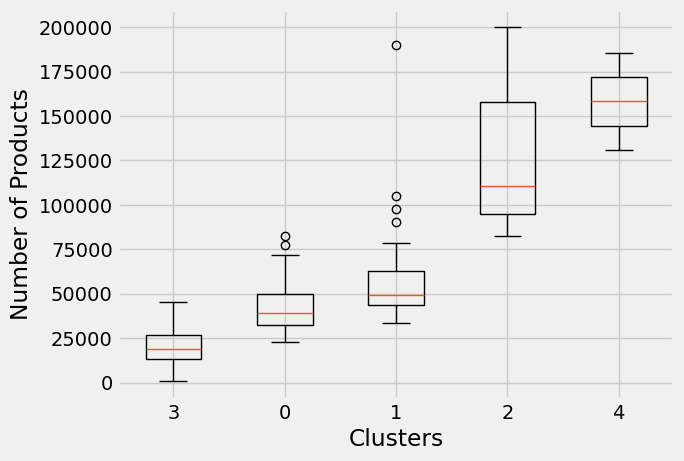

In [61]:
#plotting the relationship between the Clusters column and the Total_Products column.
plt.style.use('fivethirtyeight')
plt.Figure(figsize=(10,6))
plt.boxplot([df[df['clusters'] == i]['Total_Products'] for i in df['clusters'].unique()], labels=df['clusters'].unique())
plt.xlabel('Clusters')
plt.ylabel('Number of Products')
plt.show()


CONCLUSION

Looking at the relationships between the Clusters and the products, we can see that cluster 4 has generally has the highest number of purchases at averagely 158,280, followed by cluster 2 with an average 128,332 purchases. These two clusters have a very high number of purchases compared to the rest(the next cluster, 1, has less than 50% of the purchases cluster 2 has), which explains why they are the outliers in the PCA plot. The two clusters also have the lowest number of customers (11 and 2 for Cluster 2 and 4) respectively. 

However, while cluster 2 has relatively high number of purchases in all the products, highest in Milk, Grocery and Detergents_Paper, cluster 4 has high purchases in all products except Detergents_Paper. It has the lowest purchases for Detergents_Paper.

Cluster 1, has the third highest average number of purchases, 55,572. It is generally mid-level in the purchases of each product but second-highest in purchasing Fresh and Frozen products.

The fourth highest average number of purchases are made by cluster 0, with 42,821 purchases. This cluster have generally low purchases in most of the products except for Detergents_Paper, in which the cluster had the second most purchases.

Cluster 3, the cluster with the most number of customers, has the lowest average number of purchases, and generally low purchases all through the products.

SUGGESTIONS

One way to improve sales would be to advertise more the products to customers in clusters 3 and 0. This would help increase the purchases of the products from these clusters.

We can also introduce an offer for Detergents_Paper, targeting the high purchasing Cluster 4 who had the lowest purchases of the product.

------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------